# HW 2: Clustering and Topic Models [100 points]

Name: Doria, Atasha Frances Gayle S.

Reminder: you should not be sharing code.



## Question 1: Clustering emails using Gaussian Mixture Models

For this problem, we will be analyzing emails taken from the [Enron Email Dataset](https://www.cs.cmu.edu/~enron/). Data is provided in the `enron` data directory, with one file per email. The data set includes a combination of "spam" and "ham" emails. Spam emails are unsolicited messages intended to sell a product or scam users into providing personal information, while ham emails represent everything that is not spam. 

The language used in spam emails tends to be considerably different from typical business emails. Most spam filters leverage this difference in word frequencies to detect spam as it arrives and filter it out of email inboxes. We will use Gaussian Mixture Models (GMMs) to cluster the emails and attempt to identify groups of emails which are likely to be spam.

### Part A: Construct a list of processed documents 

Provided below is a function that returns a document present in a file given a filename. The function performs some preprocessing to (1) remove punctuation, (2),(3) remove whitespace and (4) lowercase all words. Using the makeWordList function, construct a list of processed documents.

In [ ]:
import re
import string
import codecs

def makeWordList(path):
    
    with codecs.open(path, "r", encoding='utf-8', errors='ignore') as f:
        corpus_text = f.read()

    for c in string.punctuation:
        corpus_text = corpus_text.replace(c, "")  # -- (1)
    
    text = re.sub(r'\S*\d\S*', '', corpus_text) # -- (2)
    text = re.sub(r'[^\w\s]', '', text)         # -- (3)
    
    text = text.lower().split()           # -- (4)         
    
    li = []
    for token in text:
        li.append(token)

    return " ".join(li)

In [ ]:
import os

# Used to hold processed emails.
documents = []

# Used to hold the file paths
filePaths = []

enron_dir = "enron"  

# Used loop to go through all emails in the enron folder and collect the list of results.
for filename in sorted(os.listdir(enron_dir)):
    # Used to check if the file is a text file.
    if filename.endswith(".txt"):
        path = os.path.join(enron_dir, filename)
        # Used to clean and process the email
        processed = makeWordList(path) 
        documents.append(processed)
        filePaths.append(path)

print(f"Total processed emails: {len(documents)}")

Total processed emails: 3298


### Part B: Construct a document matrix 

Next, construct a document matrix `X` as a matrix of [TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) features for each document. TF-IDF features encode information about the word frequency within a document, weighted by the frequency of the same word for corpus as a whole.

   - Use the `TfidfVectorizer` from [scikit-learn](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) to create the document matrix `X`.
   - Set `min_df=50`; this drops words that don't occur in at least 50 documents.
   - Set `stop_words="english"` and `max_df=0.8` to filter out stop-words.
   - Print the number of unique words in the vocabulary Hint: Look for the `vocabulary_` attribute in the `TfidfVectorizer` object after fitting the vectorizer to the data set. The vocabulary will also be needed in part (d).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    # Used to ignore words that appeared fewer than 50 emails.
    min_df=50,
    # Used to remove stopwords.
    stop_words="english",
    # Used to disregard words that appeared in more than 80% of the emails.
    max_df=0.8
)

# Used to build the matrix.
X = vectorizer.fit_transform(documents)
# Used to convert sparse to regular array.
X = X.toarray()                         

vocabulary = vectorizer.vocabulary_      

print(f"Number of unique words in vocabulary: {len(vocabulary)}")
print(f"Shape of document matrix X: {X.shape}")  

Number of unique words in vocabulary: 1203
Shape of document matrix X: (3298, 1203)


### Part C: Perform Clustering 

Perform clustering on the document matrix X using GMMs. 
- Use the `GaussianMixture` module from [scikit-learn](http://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) to cluster the documents.
- Set the number of clusters (mixture components) to 3.
- Print the number of documents assigned to each cluster.

In [ ]:
from sklearn.mixture import GaussianMixture

# Used to create GMM model with 3 cluters and ensure to give the same result every time it is executed.
gmm = GaussianMixture(n_components=3, random_state=42)
# Used to train the model.
gmm.fit(X)

# Used to assign each email to a cluster.
predicted = gmm.predict(X)

# Used to set 3 clusters.
for i in range(3):
    # Used to count how many emails belong to the current cluster.
    count = (predicted == i).sum()
    print(f"Cluster {i}: {count} emails")

Cluster 0: 265 emails
Cluster 1: 204 emails
Cluster 2: 2829 emails


### Part D: Characterize the clusters 

Now, we will attempt to characterize the clusters based on the frequency of spam-relevant words. 
- Select 3 "spammy" words from the vocabulary that you expect to occur frequently in spam emails and less frequently in normal business emails (e.g., 'click', 'www', 'offer'). Construct a list, `spam_indices`, storing the indices of the spammy words you selected in the vocabulary generated by `TfidfVectorizer`.
- Select 3 "hammy" words from the vocabulary you think will occur frequently in business emails and infrequently in spam emails (e.g., 'meeting', 'attached', 'review'). Construct a list, `ham_indices`, storing the indices of the hammy words you selected in the vocabulary generated by `TfidfVectorizer`.
- Use the function provided below, `plot_spam_words_by_cluster`, to plot the average TF-IDF features for your selected spammy words and hammy words for each cluster. The function takes four parameters:
    - `predicted` is predicted cluster assignments returned by `GaussianMixture.predict()`
    - `n_clusters` is the number of clusters. This should match the number of clusters from your GMM.
    - `spam_indices` is a list of indices of spammy words in the vocabulary.
    - `ham_indices` is a list of indices of hammy (typical business) words in the vocabulary.

In [ ]:
def plot_spam_words_by_cluster(predicted, n_clusters, spam_indices, ham_indices):
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Calculate mean TF-IDF features for each cluster
    mean_tfidf_spam = []
    mean_tfidf_ham = []
    for spam in spam_indices:
        mean_tfidf_spam.append([])
    for ham in ham_indices:
        mean_tfidf_ham.append([])
    
    for i in range(n_clusters):
        for j, spam_idx in enumerate(spam_indices):
            mean_tfidf_spam[j].append(X[predicted==i, spam_idx].mean())
        for j, ham_idx in enumerate(ham_indices):
            mean_tfidf_ham[j].append(X[predicted==i, ham_idx].mean())
    
    # Generate plot
    fig, ax = plt.subplots()

    ind = np.arange(n_clusters)    # the x locations for the groups
    width = 0.10         # the width of the bars

    # Plot spam bars
    for i, val in enumerate(mean_tfidf_spam):
        spam_bar = ax.bar(ind - (len(mean_tfidf_spam)-i-1)*width, val, width, color='r', bottom=0)

    # Plot ham bars
    for i, val in enumerate(mean_tfidf_ham):
        ham_bar = ax.bar(ind + (len(mean_tfidf_ham)-i)*width, val, width,
                color='y', bottom=0)

    ax.set_title('Mean TF-IDF Features by Cluster for Spam-Relevant Words')
    ax.set_xticks(ind + width / 2)
    xticklabels = []
    for i in range(n_clusters):
        xticklabels.append('Cluster ' + str(i) + '\n(n=' + str((predicted==i).sum()) + ')')
    ax.set_xticklabels(xticklabels)

    ax.legend((spam_bar[0], ham_bar[0]), ('Spammy words', 'Hammy words'))
    ax.autoscale_view()
    ax.set_ylabel('Mean TF-IDF')
    plt.show()

Spam word indices: [699, 396, 356]
Spam words found: ['offer', 'free', 'extra']
Ham word indices: [631, 74, 913]
Ham words found: ['meeting', 'attached', 'review']


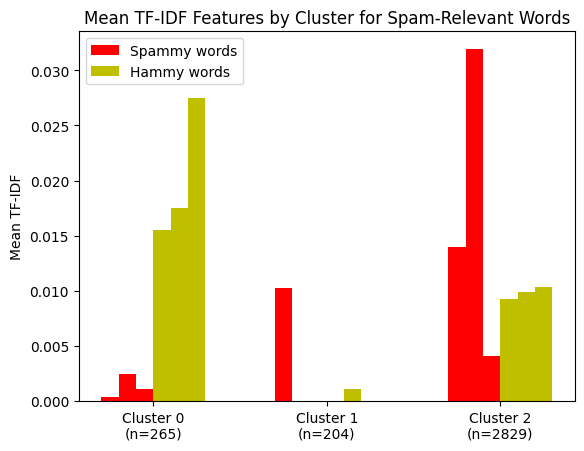

In [ ]:
# Used to define spam words 
spam_words = ['offer', 'free', 'extra']

# Used to find the column for each spam words and check if it exists in the vocabulary.
spam_indices = [vocabulary[w] for w in spam_words if w in vocabulary]
print("Spam word indices:", spam_indices)
print("Spam words found:", [w for w in spam_words if w in vocabulary])


# Used to find the column index for each ham word if it exist in the vocabulary.
ham_words = ['meeting', 'attached', 'review']
ham_indices = [vocabulary[w] for w in ham_words if w in vocabulary]
print("Ham word indices:", ham_indices)
print("Ham words found:", [w for w in ham_words if w in vocabulary])

plot_spam_words_by_cluster(predicted, n_clusters=3, 
                           spam_indices=spam_indices, 
                           ham_indices=ham_indices)

### Part E: Interpret results 

From the plot generated in part (d), do any of the clusters correspond to spam emails, based on the frequency of spammy and hammy words? Do any of the clusters appear to correspond to typical business emails (ham)? 

Re-run your analysis with a different choice for the number of clusters in your GMM (e.g., `n_clusters=5` or `n_clusters=2`). How does changing the number of clusters affect your results? Does one choice of `n_clusters` appear better than another for locating clusters of spam emails?

***After trying to change the number of clusters, I noticed that 2 clusters shows that it mixes regular business emails and spam emails together in a huge group which does not properly separate other spam emails. While 3 clusters was just right as it separates business emails, spam emails, and system-generated ones. Then 5 clusters are too complex as it splits spam emails into two different cluster, as well as the hammy emails which also inefficient when identifying emails. With that, having 3 clusters is the best clustring decision as its results in better filttering.***

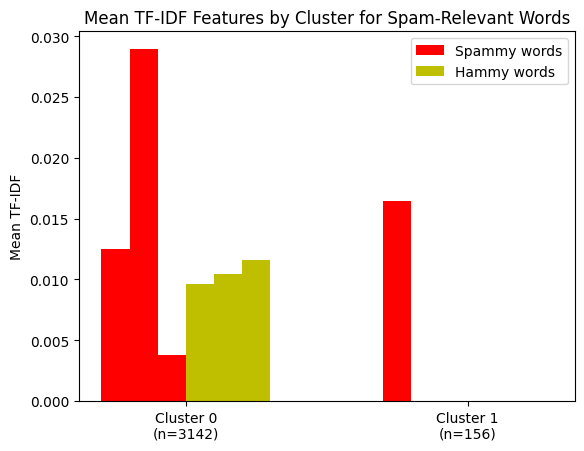

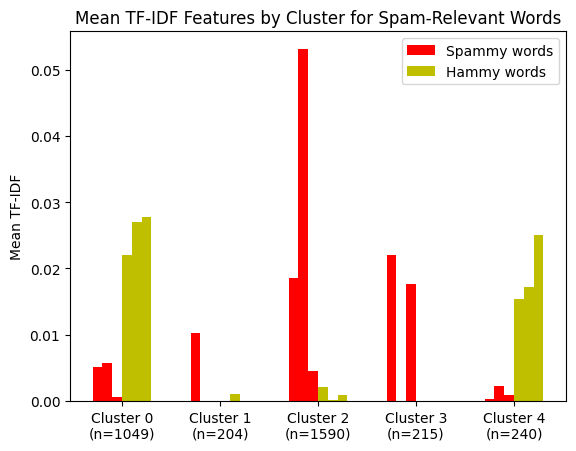

In [ ]:
# Used to re-run analysis for 2 clusters.
gmm2 = GaussianMixture(n_components=2, random_state=42)
gmm2.fit(X)
predicted2 = gmm2.predict(X)
plot_spam_words_by_cluster(predicted2, n_clusters=2,
                           spam_indices=spam_indices,
                           ham_indices=ham_indices)

# Used to re-run analysis for 5 clusters.
gmm5 = GaussianMixture(n_components=5, random_state=42)
gmm5.fit(X)
predicted5 = gmm5.predict(X)
plot_spam_words_by_cluster(predicted5, n_clusters=5,
                           spam_indices=spam_indices,
                           ham_indices=ham_indices)

## Question 2: Latent "Purposes" in Mobile Apps


Think of Android applications as "documents", where "words" are the "permissions" that each app requests. Each app has a set of latent "purposes" (topics); a "purpose" may be a specific task (such as taking photographs and uploading them to the internet), and an application may have a mixture of purposes of varying strength.

Can we uncover these purposes from a dataset of Android applications and the permissions they request?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

### Part A: Load the data 

The [dataset](http://www.mariofrank.net/andrApps/) contains ~180,000 applications from the Android app store, including each app's name, description and permissions requested. For more about Android app permissions, see [this report](http://www.pewinternet.org/2015/11/10/an-analysis-of-android-app-permissions/).

   * Download the data and unzip it into the same folder as this notebook.
   * Rename the CSV file to "android.csv".
   * Run the cells below to load the data into the notebook.

This may take up ~2GB of RAM.

In [ ]:
df = pd.read_csv("android.csv", sep=",",  thousands=",")

In [ ]:
df["Number of ratings"] = df["Number of ratings"].astype(int) # fix data type
df = df.drop_duplicates(subset=["App"]).reset_index(drop=True)

In [ ]:
df.head(n=3)

### Part B: Convert each app into a "document" 

The code below does the following:

   * Filter out all the columns except the permission columns.
   * Convert this dataframe into a numpy matrix.

There are thus 180295 apps (documents) and 173 permissions (words).

   - `X` is the "document" or "word-frequency" matrix.
   - `permission_columns` contains the words ordered by their column index in X.
   - `app_names` contains the application names ordered by their row index in X.
   - `app_ratings` contains the *number* of application ratings (not the ratings themselves).

In [ ]:
permissionColumns = list(df.columns[10:])
appNames = list(df["App"])
appRatings = np.array(df["Number of ratings"])
dfPerms = df[permissionColumns]
X = dfPerms.as_matrix()
#del df # uncomment to free up RAM
#del df_perms # uncomment to free up RAM

# Used to show the final rows and columns of the matrix X.
print(f"Shape of X: {X.shape}") 

### Part C: Downweight "stop-words" 
There are some permissions requested by almost all applications (like "INTERNET"), they are similar to stop-words ("the", "and", etc.) in natural language. We can downweight them by TF-IDF normalization.

   * Use the `TfidfTransformer` class in `scikit-learn` to transform X.

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
# Used to transform the permission matrix X to lower the weight of overly common permissions.
X = tfidf.fit_transform(X)

print(f"Shape of X after TF-IDF: {X.shape}")

### Part D: Discover 10 "topics" [2.5 points]

   * Use the `LatentDirichletAllocation` class in `scikit-learn` to fit 10 topics to the data.
   * Use 10 max iterations, set `n_jobs=-1` to use all cores on your machine (if it helps).
   * Feel free to understand and play around with other parameters.
   * This may take around 3 minutes to run.

In [ ]:
%%time
from sklearn.decomposition import LatentDirichletAllocation

# Used to create the LDA model.
ldaModel = LatentDirichletAllocation(
    # Used to discover 10 topics.
    n_components=10,
    # Used to set the maximum training iterations.
    max_iter=10,
    # Used to use all CPU cores to speed up processing.
    n_jobs=-1,
    # Used to ensure same result when re-running.
    random_state=42
)

# Used to train the model and convert apps into a document-topic matrix.
docTopicMatrix = ldaModel.fit_transform(X)

print(f"Shape of docTopicMatrix: {docTopicMatrix.shape}")

Now each app can be viewed as a distribution over these 10 topics, and each topic is a distribution over all the permissions in the data.

### Part E: List the top 10 "words" in each topic 

Do any of the topics correspond to meaningful app "purposes"? List the ones you find meaningful below:

   * Topic #i: "your interpretation"

In [ ]:
# Used to print the top words for each discovered topic.
def printTopWords(model, featureNames, nTop=10):
    # Used to go through each topic and its weight components.
    for topicIdx, topic in enumerate(model.components_):
        # Used to find the indices of the top 10 highest-weighted permissions.
        topIndices = topic.argsort()[-nTop:][::-1]
        # Used to map indices back to the actual permission text labels.
        topWords = [featureNames[i] for i in topIndices]
        # Used to print top 10 permission words.
        print(f"Topic #{topicIdx}: {', '.join(topWords)}")
    print()

printTopWords(ldaModel, permissionColumns, nTop=10)

*** WRITE YOUR ANSWER HERE IN TEXT ***

### Part F: For each topic, list the top 3 apps with at least 100000 ratings having the highest probability assigned to that topic 

   - This further helps us understand what the topics actually mean.
   - However, the data is noisy and this exercise may result in listing a bunch of obscure apps.
   - Hence, filtering out all apps with less than 100000 ratings may help.

In [ ]:
# Used to create a filter for apps that have at least 100k ratings.
popularMask = appRatings >= 100000

# Used to filter the topic matrix and keep only popular apps.
popularDocTopics = docTopicMatrix[popularMask]

# Used to get the names of the popular apps.
popularNames = [appNames[i] for i in np.where(popularMask)[0]]

print(f"Number of popular apps (>=100k ratings): {popularMask.sum()}")
print()

# Used to find top 3 popular apps for each topic.
for topicIdx in range(10):
    # Used to get the topic scores for the current topic across all popular apps.
    topicScores = popularDocTopics[:, topicIdx]
    # Used to get the indices of the top 3 apps with the highest scores for this topic.
    top3Indices = topicScores.argsort()[-3:][::-1]
    # Used to get the actual names of the top 3 apps.
    top3Apps = [popularNames[i] for i in top3Indices]
    print(f"Topic #{topicIdx}: {top3Apps}")

### Part G: Visualize the document-topic proportion matrix in 2-D using t-SNE 

Does our reduced dimensional space contain any structure? Visualize the documents (in the topic-space) using t-SNE.

   * Use `TSNE` from `scikit-learn`.
   * Set the angle to 0.99 and init to 'PCA'. Pick any learning rate that gives you a visually pleasing result.
   * You may `fit` TSNE to a sample of the data (>1000 documents) instead of the full data.
   * Remember to call `fit_transform` to obtain your 2-D data.
   * Plot the t-SNE dimensions as a scatterplot.
   * Color each point based on its most probable topic. Make sure you include a legend (10 colors).
   
Clusters in the t-SNE plot indicate groups of apps that have similar topics.

In [ ]:
%%time
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Used to set a fixed seed for reproducibility.
np.random.seed(42)

# Used to define how many apps to sample for t-SNE.
sampleSize = 3000

# Used to randomly select app indices from the full document-topic matrix.
sampleIdx = np.random.choice(len(docTopicMatrix), sampleSize, replace=False)

# Used to get the topic distributions of only the sampled apps.
sampleTopics = docTopicMatrix[sampleIdx]

# Used to create the t-SNE model.
tsneModel = TSNE(
    # Used for 2 dimensions for plotting.
    n_components=2,
    # Used to set the angle as instructed.
    angle=0.99,
    # Used to initialize with PCA.
    init='pca',
    # Used to control how fast the model learns.
    learning_rate=200,
    # Used to ensure same result when re-running.
    random_state=42
)

# Used to fit the model and reduce dimensions to 2D.
tsneResult = tsneModel.fit_transform(sampleTopics)

# Used to find the most probable topic for each sampled app.
dominantTopics = sampleTopics.argmax(axis=1)

plt.figure(figsize=(10, 8))

# Used to crreate 10 distinct colors per topic.
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Used to plot each topic's apps as a separate colored group.
for topicIdx in range(10):
    # Used to create a boolean mask for apps belonging to this topic.
    mask = dominantTopics == topicIdx
    plt.scatter(
        tsneResult[mask, 0],   
        tsneResult[mask, 1],   
        color=colors[topicIdx],
        label=f'Topic {topicIdx}',
        alpha=0.5,             
        s=10                  
    )

plt.legend(loc='best', markerscale=3, title="Dominant Topic")
plt.title('t-SNE Visualization of Apps in Topic Space')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()